# University of Manitoba  
**Winter 2026**

**Student Name 1:** Prince Kanani  
**Student ID:** 8029853


**Student Name 2:** Joshua Mudiwa  
**Student ID:** 7954458

**Course:** DATA 2010 A01 – Tools and Techniques  
**Project Weight:** 15%  
**Instructor:** Lie Ding  
**Date:** 18th February 2026  

**Data Source:** Kaggle — Olympic Summer and Winter Games (1896–2024)  
**Research Focus:** Compare medal outcomes and participation patterns over time (e.g., sex proportions, age-group trends, and top medal countries).

---

# DATA 2010 Project — Olympics (1896–2024)

This notebook follows a clear flow:

1) **Load data** (Cells **1–2**)  
2) **Inspect dataset** (Cells **3–7**)  
3) **Data cleaning** (Cells **8–14**)  
4) **Missing values + outliers** (Cells **15–16**)  
5) **Feature engineering** (Cells **17–19**)  
6) **Interesting facts + summaries** (Cells **20–27**)  
7) **Plots** (Cells **28–29**)  
8) **Export cleaned data** (Cell **30**)  

In [48]:
# 1) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [49]:
# 2) Load dataset
# Update the path if needed.
path = r"C:\Users\princ\OneDrive\Documents\OneDrive\Desktop\olympics_1896_2024.csv"
df = pd.read_csv(path, low_memory=False)

print("Raw shape:", df.shape)
df.head()


Raw shape: (290697, 8)


,sex,age,team,year,season,sports,event,medal
0,M,72,Great Britain,1948,Summer,Art Competitions,"Art Competitions Mixed Sculpturing, Medals And...",NaN
1,M,72,Latvia,1936,Summer,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN
2,M,72,Austria,1936,Summer,Equestrianism,"Equestrianism Men's Dressage, Individual",NaN
3,M,72,Austria,1936,Summer,Equestrianism,"Equestrianism Men's Dressage, Team",NaN
4,M,72,Netherlands,1928,Summer,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN


In [50]:
# 3) Standardize column names (prevents Year vs year issues)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print("Columns:", df.columns.tolist())


Columns: ['sex', 'age', 'team', 'year', 'season', 'sports', 'event', 'medal']


In [51]:
# 4) Basic coverage checks
print("Year range:", df["year"].min(), "to", df["year"].max())
print("Seasons:", df["season"].dropna().unique())


Year range: 1896 to 2024
Seasons: ['Summer' 'Winter']


In [52]:
# 5) Quick category distributions
print("\nSex counts (including missing):")
print(df["sex"].value_counts(dropna=False))

print("\nMedal counts (including missing):")
print(df["medal"].value_counts(dropna=False).head(15))



Sex counts (including missing):
sex
M    202596
F     88101
Name: count, dtype: int64

Medal counts (including missing):
medal
NaN       247941
Gold       14407
Bronze     14333
Silver     14016
Name: count, dtype: int64


In [53]:
# 6) Missing values summary (top 20)
missing = df.isna().sum().sort_values(ascending=False)
print(missing.head(20))


medal     247941
sex            0
age            0
team           0
year           0
season         0
sports         0
event          0
dtype: int64


In [54]:
# 7) How many teams / sports / events?
print("# unique teams:", df["team"].nunique(dropna=True))
print("# unique sports:", df["sports"].nunique(dropna=True))
print("# unique events:", df["event"].nunique(dropna=True))


# unique teams: 1151
# unique sports: 92
# unique events: 1534


In [55]:
# 8) Create a working copy for cleaning
df_clean = df.copy()


In [56]:
# 9) Strip whitespace from all text columns (does NOT turn NaN into 'nan')
text_cols = df_clean.select_dtypes(include="object").columns
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()


In [57]:
# 10) Fix data type: year must be numeric
df_clean["year"] = pd.to_numeric(df_clean["year"], errors="coerce")
df_clean = df_clean.dropna(subset=["year"])
df_clean["year"] = df_clean["year"].astype(int)

print("Cleaned year range:", df_clean["year"].min(), "to", df_clean["year"].max())
print("Shape after year cleaning:", df_clean.shape)


Cleaned year range: 1896 to 2024
Shape after year cleaning: (290697, 8)


In [58]:
# 11) Fix data type: age to numeric (keep float for averages)
if "age" in df_clean.columns:
    df_clean["age"] = pd.to_numeric(df_clean["age"], errors="coerce")
    print("Missing age:", df_clean["age"].isna().sum())
    print("Age range (non-missing):", df_clean["age"].min(), "to", df_clean["age"].max())
else:
    print("Column 'age' not found in this dataset.")


Missing age: 0
Age range (non-missing): 10 to 72


In [59]:
# 12) Standardize medal column
# Fill missing medals with "No medal" and normalize text formatting.
df_clean["medals"] = df_clean["medal"].fillna("No medal")
df_clean["medals"] = df_clean["medal"].str.title().replace({"No Medal": "No medal"})
print(df_clean["medals"].value_counts().head(10))


medals
Gold      14407
Bronze    14333
Silver    14016
Name: count, dtype: int64


In [60]:
# 13) Standardize sex values (M/F)
df_clean["sex"] = df_clean["sex"].replace({"Male": "M", "Female": "F"})
print(df_clean["sex"].value_counts(dropna=False))


sex
M    202596
F     88101
Name: count, dtype: int64


In [61]:
# 14) Remove exact duplicate rows (safe)
dup_count = df_clean.duplicated().sum()
print("Exact duplicates found:", dup_count)

df_clean = df_clean.drop_duplicates()
print("Shape after dropping exact duplicates:", df_clean.shape)


Exact duplicates found: 35568
Shape after dropping exact duplicates: (255129, 9)


In [62]:
# 15) Outlier handling: flag suspicious ages (do NOT delete without justification)
if "age" in df_clean.columns:
    df_clean["age_flag_suspicious"] = (df_clean["age"] < 10) | (df_clean["age"] > 60)
    print("Suspicious age rows:", df_clean["age_flag_suspicious"].sum())

    # Show a few examples
    display(df_clean.loc[df_clean["age_flag_suspicious"], ["age","sports","event","year"]].head(20))


Suspicious age rows: 287


,age,sports,event,year
0,72,Art Competitions,"Art Competitions Mixed Sculpturing, Medals And...",1948
1,72,Art Competitions,"Art Competitions Mixed Painting, Paintings",1936
2,72,Equestrianism,"Equestrianism Men's Dressage, Individual",1936
3,72,Equestrianism,"Equestrianism Men's Dressage, Team",1936
4,72,Art Competitions,"Art Competitions Mixed Painting, Paintings",1928
5,72,Shooting,"Shooting Men's Running Target, Single Shot",1920
6,72,Shooting,"Shooting Men's Running Target, Single Shot, Team",1920
7,72,Shooting,"Shooting Men's Running Target, Double Shot, Team",1920
8,71,Equestrianism,"Equestrianism Mixed Dressage, Individual",2012
9,71,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",1948


In [63]:
# 16) Missing value handling: impute age using median within (sex, sport)
if "age" in df_clean.columns:
    df_clean["age_imputed"] = df_clean["age"]

    group_median = df_clean.groupby(["sex", "sports"])["age"].transform("median")
    overall_median = df_clean["age"].median()

    df_clean["age_imputed"] = df_clean["age_imputed"].fillna(group_median)
    df_clean["age_imputed"] = df_clean["age_imputed"].fillna(overall_median)

    print("Missing age BEFORE:", df_clean["age"].isna().sum())
    print("Missing age AFTER :", df_clean["age_imputed"].isna().sum())


Missing age BEFORE: 0
Missing age AFTER : 0


In [64]:
# 17) Feature engineering: did the athlete win a medal?
df_clean["won_medal"] = df_clean["medal"].isin(["Gold", "Silver", "Bronze"])
df_clean[["medal","won_medal"]].head()


,medal,won_medal
0,NaN,False
1,NaN,False
2,NaN,False
3,NaN,False
4,NaN,False


In [65]:
# 18) Feature engineering: medal points (Gold=3, Silver=2, Bronze=1, No medal=0)
points_map = {"Gold": 3, "Silver": 2, "Bronze": 1, "No medal": 0}
df_clean["medal_points"] = df_clean["medal"].map(points_map).fillna(0).astype(int)

df_clean[["medal","medal_points"]].head()


,medal,medal_points
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0


In [66]:
# 19) Feature engineering: decade
df_clean["decade"] = (df_clean["year"] // 10) * 10
df_clean["decade"].value_counts().sort_index().head(15)

years = sorted(df_clean["year"].dropna().unique())
full = set(range(min(years), max(years) + 1))
missing_years = sorted(full - set(years))

print("Min year:", min(years))
print("Max year:", max(years))
print("Number of Olympic years present:", len(years))
print("Missing years within range (gaps):", missing_years[:30])
print("Total missing years within range:", len(missing_years))


Min year: 1896
Max year: 2024
Number of Olympic years present: 38
Missing years within range (gaps): [1897, 1898, 1899, 1901, 1902, 1903, 1905, 1907, 1909, 1910, 1911, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1921, 1922, 1923, 1925, 1926, 1927, 1929, 1930, 1931, 1933, 1934, 1935]
Total missing years within range: 91


In [67]:
# 20) Interesting fact: sex proportions (counts + %)
sex_counts = df_clean["sex"].value_counts(dropna=False)
sex_percent = (sex_counts / len(df_clean) * 100).round(2)

out = pd.DataFrame({"count": sex_counts, "percent": sex_percent})
out


,count,percent
sex,,
M,177018,69.38
F,78111,30.62


In [68]:
# 21) Interesting fact: age group distribution 
age_col = "age_imputed" if "age_imputed" in df_clean.columns else ("age" if "age" in df_clean.columns else None)

if age_col is None:
    print("No age column available.")
else:
    bins = [0, 15, 18, 25, 30, 35, 40, 50, 100]
    labels = ["<16", "16-18", "19-25", "26-30", "31-35", "36-40", "41-50", "51+"]

    df_clean["age_group"] = pd.cut(df_clean[age_col], bins=bins, labels=labels, right=True)
    age_group_counts = df_clean["age_group"].value_counts(dropna=False).sort_index()
    age_group_percent = (age_group_counts / age_group_counts.sum() * 100).round(2)

    pd.DataFrame({"count": age_group_counts, "percent": age_group_percent})

result = pd.DataFrame({"count": age_group_counts, "percent": age_group_percent})
display(result)     
# or
print(result)        


,count,percent
age_group,,
<16,2917,1.14
16-18,16230,6.36
19-25,122217,47.90
26-30,69066,27.07
31-35,28137,11.03
36-40,9495,3.72
41-50,5593,2.19
51+,1474,0.58


            count  percent
age_group                 
<16          2917     1.14
16-18       16230     6.36
19-25      122217    47.90
26-30       69066    27.07
31-35       28137    11.03
36-40        9495     3.72
41-50        5593     2.19
51+          1474     0.58


In [69]:
# 22) Create medalists-only data (exclude 'No medal')
medalists = df_clean[df_clean["medal"].isin(["Gold","Silver","Bronze"])].copy()
print("Medalists shape:", medalists.shape)


Medalists shape: (36217, 15)


In [70]:
# 23) Medal counts by country 
# Meaning: counts medal "rows" in the dataset.
# NOTE: Team events inflate this count because every athlete on the team has a medal row.

# Keep only medal-winning rows
# Count medals by country using country name column "team"
country_medals_athlete = medalists.groupby("team").size().sort_values(ascending=False)

# Show top 10
country_medals_athlete.head(10)

team
United States    4660
Soviet Union     2025
Germany          1800
Great Britain    1626
France           1544
Italy            1429
Sweden           1223
Australia        1220
Canada           1087
Russia           1082
dtype: int64

In [71]:
# 25) Top 7 countries with most medals (EVENT-MEDAL method)
# Meaning: counts unique medals per event per country.
# This avoids team-event inflation by counting each (year, event, team, medal) only once.

# Deduplicate medals so team medals count once per event
event_medals = medalists.drop_duplicates(["year", "event", "team", "medal"])
print("Event-medals shape (unique event medals):", event_medals.shape)

# Count unique event medals by country
country_medals_event = event_medals.groupby("team").size().sort_values(ascending=False)

# Top 7 countries
top7 = country_medals_event.head(7)
top7

Event-medals shape (unique event medals): (20890, 15)


team
United States    2875
Soviet Union     1172
Germany          1017
Great Britain     915
France            886
Italy             768
China             696
dtype: int64

In [72]:
# 24) Countries with the least medals (among medal-winning NOCs)
least = country_medals_event.tail(10)
least


team
Ivory Coast                  1
Italia                       1
Irene                        1
Ireland-3                    1
Ireland-2                    1
Independent Rowing Club-3    1
Hurlingham-2                 1
Humbug V                     1
Hong Kong-2                  1
Zut                          1
dtype: int64

In [73]:
# 26) Countries with exactly 1 medal (athlete-medal method)
one_medal = country_medals_athlete[country_medals_athlete == 1]

print("Number of countries with exactly 1 medal:", one_medal.shape[0])
print("\nCountries with exactly 1 medal:")
print(one_medal.sort_index())

Number of countries with exactly 1 medal: 66

Countries with exactly 1 medal:
team
Andorra                         1
Barbados                        1
Berliner Ruderclub              1
Bolivia                         1
Bonaparte                       1
                               ..
Tonga                           1
Turkmenistan                    1
Turquoise-1                     1
United States Virgin Islands    1
Widgeon                         1
Length: 66, dtype: int64


In [74]:
# 27) Countries with most Gold / Silver / Bronze (event-medal method)
# Using "team" because this dataset does not include NOC country codes.

gold = (
    event_medals[event_medals["medal"] == "Gold"]
    .groupby("team").size()
    .sort_values(ascending=False)
    .head(10)
)

silver = (
    event_medals[event_medals["medal"] == "Silver"]
    .groupby("team").size()
    .sort_values(ascending=False)
    .head(10)
)

bronze = (
    event_medals[event_medals["medal"] == "Bronze"]
    .groupby("team").size()
    .sort_values(ascending=False)
    .head(10)
)

print("Top Gold:\n", gold)
print("\nTop Silver:\n", silver)
print("\nTop Bronze:\n", bronze)

Top Gold:
 team
United States    1141
Soviet Union      459
Germany           321
Great Britain     281
China             278
France            274
Italy             265
Russia            211
Sweden            206
Japan             202
dtype: int64

Top Silver:
 team
United States    925
Soviet Union     365
Germany          351
Great Britain    317
France           285
Italy            236
China            223
Sweden           215
Russia           200
Australia        190
dtype: int64

Top Bronze:
 team
United States    809
Soviet Union     348
Germany          345
France           327
Great Britain    317
Italy            267
Sweden           244
Australia        226
Russia           217
Japan            210
dtype: int64


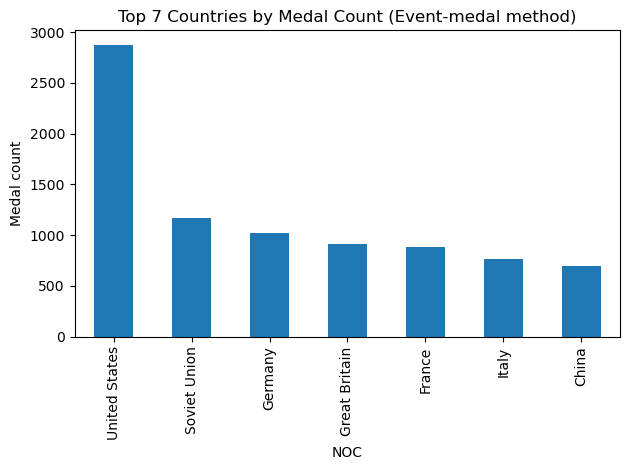

In [75]:
# 28) Plot: Top 7 countries by medals (event-medal method)
plt.figure()
top7.plot(kind="bar")
plt.title("Top 7 Countries by Medal Count (Event-medal method)")
plt.xlabel("NOC")
plt.ylabel("Medal count")
plt.tight_layout()
plt.show()


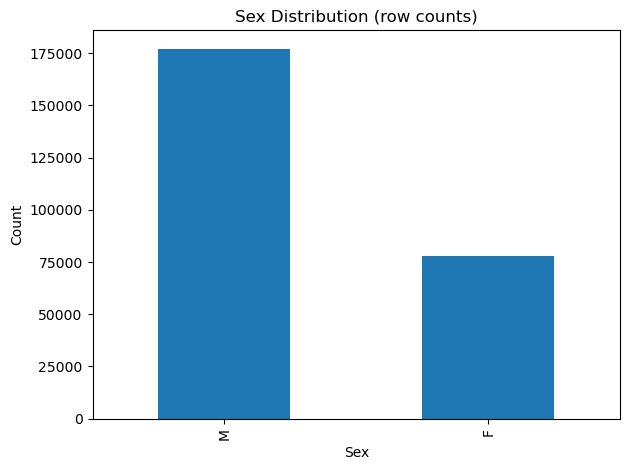

In [76]:
# 29) Plot: Sex distribution (rows)
sex_counts = df_clean["sex"].value_counts(dropna=False)
plt.figure()
sex_counts.plot(kind="bar")
plt.title("Sex Distribution (row counts)")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Research Question 1
## Demographics and medal outcomes: age groups, sex, parity trends, and peak-age patterns
We split RQ1 into three focused sub-questions so each is supported by clear plots:
- **RQ1a:** How do medal outcomes vary by **age group** and **sex**?
- **RQ1b:** Which decades show the **largest changes in gender parity** (male vs female shares)?
- **RQ1c:** How do **peak-age patterns** change across decades (median + IQR of medalist ages)?

Run the cells in order.


### RQ1-1: Imports + folders

In [77]:
# RQ1-1) Imports (run once)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)


### RQ1-2: Standardize column names + create helper columns

In [78]:
# RQ1-2) Standardize column names (safe even if already standardized)
df_clean.columns = [c.strip().lower().replace(" ", "_") for c in df_clean.columns]

# Required columns check
required = ["year", "sex", "sport", "medal"]
missing = [c for c in required if c not in df_clean.columns]
print("Missing required columns:", missing)

# Create decade (used in parity and peak-age plots)
df_clean["decade"] = (df_clean["year"] // 10) * 10

# Choose age column (use imputed age if available)
age_col = "age_imputed" if "age_imputed" in df_clean.columns else ("age" if "age" in df_clean.columns else None)
print("Using age column:", age_col)


Missing required columns: ['sport']
Using age column: age_imputed


### RQ1-3: Create age groups (Olympics-style bins)

In [79]:
# RQ1-3) Create age groups (needed for RQ1a)
age_order = ["<16", "16-18", "19-25", "26-30", "31-35", "36-40", "41-50", "51+"]

if "age_group" not in df_clean.columns:
    if age_col is None:
        print("No age column available.")
    else:
        bins = [0, 15, 18, 25, 30, 35, 40, 50, 100]
        df_clean["age_group"] = pd.cut(df_clean[age_col], bins=bins, labels=age_order, right=True)

# Force consistent category order for plotting
if "age_group" in df_clean.columns:
    df_clean["age_group"] = pd.Categorical(df_clean["age_group"], categories=age_order, ordered=True)

print(df_clean["age_group"].value_counts(dropna=False).sort_index())


age_group
<16        2917
16-18     16230
19-25    122217
26-30     69066
31-35     28137
36-40      9495
41-50      5593
51+        1474
Name: count, dtype: int64


### RQ1-4: Create medalists subset (Gold/Silver/Bronze only)

In [80]:
# RQ1-4) Medalists subset (used in RQ1a and RQ1c)
medalists = df_clean[df_clean["medal"].isin(["Gold", "Silver", "Bronze"])].copy()
print("Medalist rows:", medalists.shape)


Medalist rows: (36217, 15)


## RQ1a: Medal outcomes by age group and sex
### Plot 1: 100\% stacked bar (sex share within each age group)
This makes small groups (e.g., 40+) easier to compare than raw counts.

C:\Users\princ\AppData\Local\Temp\ipykernel_31972\2869085733.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medalists.groupby(["age_group", "sex"])


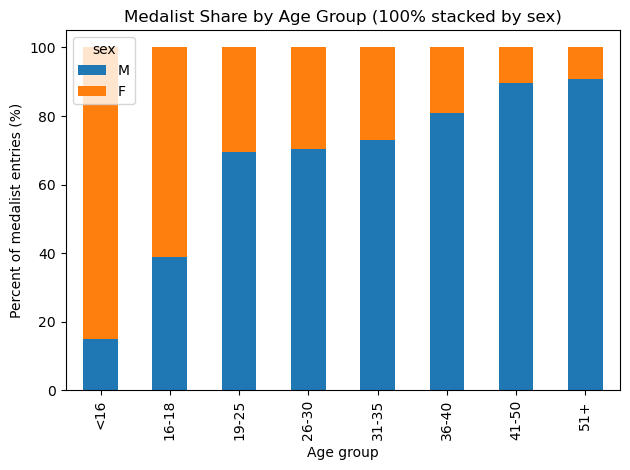

In [81]:
# RQ1a Plot 1) 100% stacked bar: sex proportions among medalists within each age group

tab = (
    medalists.groupby(["age_group", "sex"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both columns exist
for s in ["M", "F"]:
    if s not in tab.columns:
        tab[s] = 0

tab = tab[["M", "F"]].reindex(age_order)

prop = tab.div(tab.sum(axis=1), axis=0) * 100

ax = prop.plot(kind="bar", stacked=True)
ax.set_title("Medalist Share by Age Group (100% stacked by sex)")
ax.set_xlabel("Age group")
ax.set_ylabel("Percent of medalist entries (%)")
plt.tight_layout()
plt.savefig("figures/RQ1a_plot1_100pct_stacked_agegroup_sex.png", dpi=300)
plt.show()


### Plot 2: Medal-type distribution by age group (Gold/Silver/Bronze share)
This directly shows how medal outcomes differ across age groups.

C:\Users\princ\AppData\Local\Temp\ipykernel_31972\3924769401.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medalists.groupby(["age_group", "medal"])


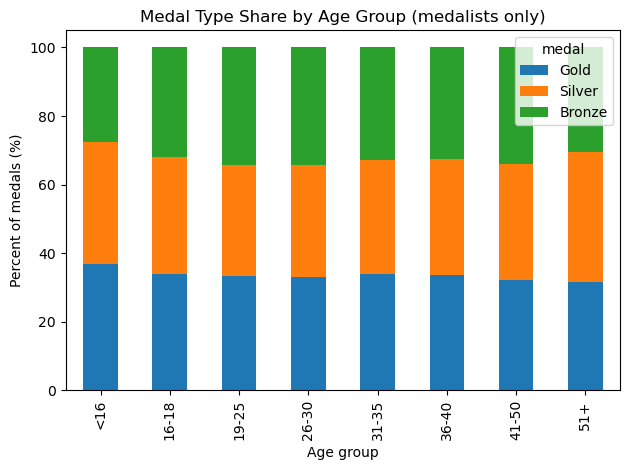

In [82]:
# RQ1a Plot 2) Medal-type distribution by age group (shares)

medal_tab = (
    medalists.groupby(["age_group", "medal"])
    .size()
    .unstack(fill_value=0)
)

# Ensure medal columns exist consistently
for m in ["Gold", "Silver", "Bronze"]:
    if m not in medal_tab.columns:
        medal_tab[m] = 0
medal_tab = medal_tab[["Gold", "Silver", "Bronze"]].reindex(age_order)

medal_share = medal_tab.div(medal_tab.sum(axis=1), axis=0) * 100

ax = medal_share.plot(kind="bar", stacked=True)
ax.set_title("Medal Type Share by Age Group (medalists only)")
ax.set_xlabel("Age group")
ax.set_ylabel("Percent of medals (%)")
plt.tight_layout()
plt.savefig("figures/RQ1a_plot2_medal_type_share_by_agegroup.png", dpi=300)
plt.show()


## RQ1b: Largest changes in gender parity across decades
### Plot 3: Male + Female share over decades (same graph)
Shows convergence toward parity (0.5).

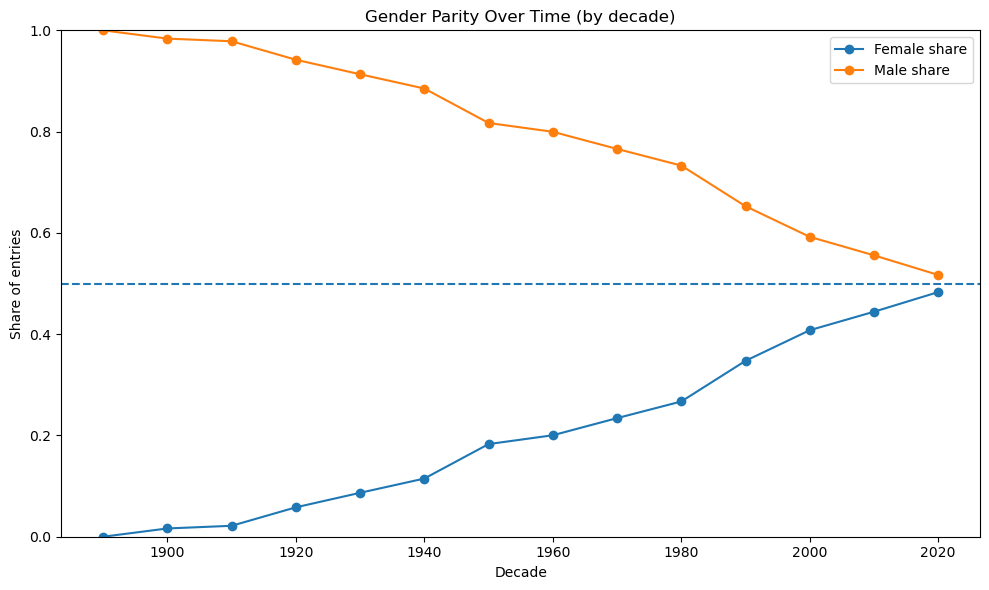

In [83]:
# RQ1b Plot 3) Gender parity over decades (male + female share on same plot)

tmp = df_clean.dropna(subset=["decade", "sex"]).copy()

parity = (
    tmp.groupby(["decade", "sex"])
    .size()
    .unstack(fill_value=0)
)

for s in ["M", "F"]:
    if s not in parity.columns:
        parity[s] = 0

parity["female_share"] = parity["F"] / (parity["F"] + parity["M"])
parity["male_share"] = parity["M"] / (parity["F"] + parity["M"])

plt.figure(figsize=(10,6))
plt.plot(parity.index, parity["female_share"], marker="o", label="Female share")
plt.plot(parity.index, parity["male_share"], marker="o", label="Male share")
plt.axhline(0.5, linestyle="--")

plt.title("Gender Parity Over Time (by decade)")
plt.xlabel("Decade")
plt.ylabel("Share of entries")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig("figures/RQ1b_plot3_gender_parity_by_decade.png", dpi=300)
plt.show()


### Plot 4: Decade-to-decade change in female share (largest changes)
This plot directly answers ``largest changes'' by showing absolute changes between consecutive decades.

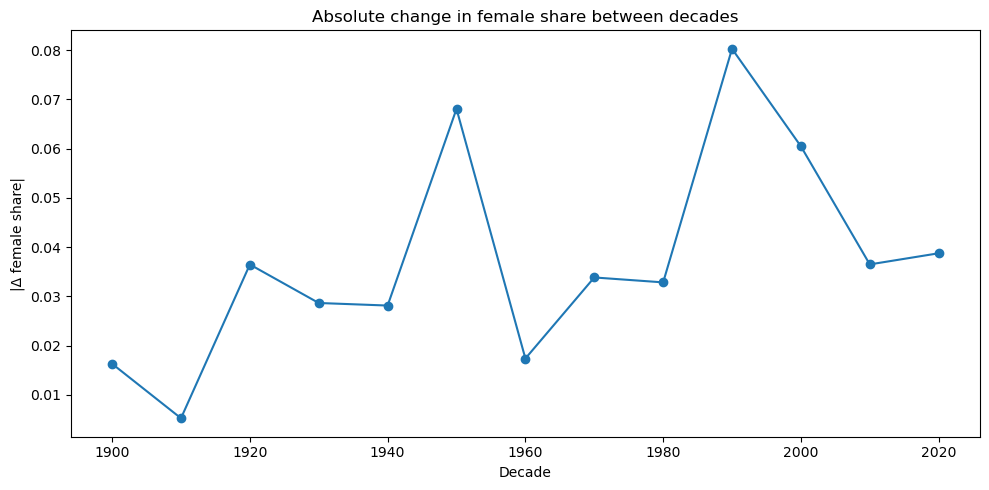

decade
1990    0.080276
1950    0.068075
2000    0.060473
2020    0.038764
2010    0.036503
Name: female_share, dtype: float64

In [84]:
# RQ1b Plot 4) Largest parity changes: absolute decade-to-decade change in female share

parity_change = parity["female_share"].diff().abs()

plt.figure(figsize=(10,5))
plt.plot(parity_change.index, parity_change.values, marker="o")
plt.title("Absolute change in female share between decades")
plt.xlabel("Decade")
plt.ylabel("|Δ female share|")
plt.tight_layout()
plt.savefig("figures/RQ1b_plot4_abs_change_female_share.png", dpi=300)
plt.show()

# Show the top 5 biggest changes in a small table
top5 = parity_change.sort_values(ascending=False).head(5)
top5


## RQ1c: Peak-age patterns across decades
### Plot 5: Median + IQR of medalist ages by decade (one sport)
This avoids difficult boxplot interpretation and shows both central tendency and spread.

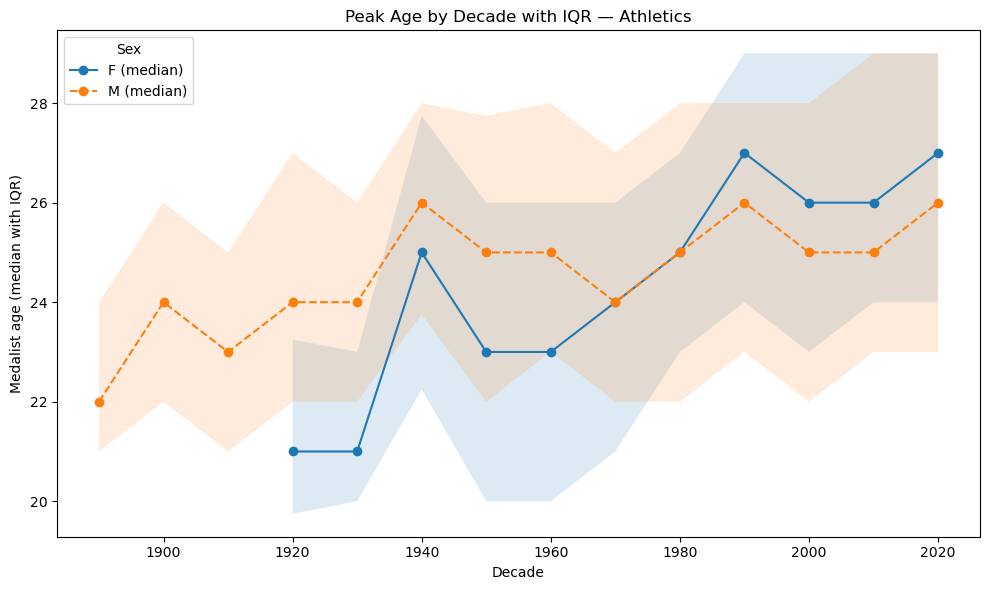

In [85]:
# RQ1c Plot 5) Peak-age pattern by decade with IQR (choose one sport)
sport_name = "Athletics"  # change if needed

if age_col is None:
    print("No age column available for peak-age analysis.")
else:
    medalists_age = medalists.dropna(subset=[age_col]).copy()
    sport_df = medalists_age[medalists_age["sports"] == sport_name].copy()

    if sport_df.empty:
        print("Sport not found:", sport_name)
    else:
        def decade_quantiles(df, sex_value):
            sub = df[df["sex"] == sex_value]
            g = sub.groupby("decade")[age_col]
            return pd.DataFrame({
                "median": g.median(),
                "q25": g.quantile(0.25),
                "q75": g.quantile(0.75)
            }).reset_index().sort_values("decade")

        F = decade_quantiles(sport_df, "F")
        M = decade_quantiles(sport_df, "M")

        plt.figure(figsize=(10,6))

        # IQR shading
        if len(F) > 0:
            plt.fill_between(F["decade"], F["q25"], F["q75"], alpha=0.15)
        if len(M) > 0:
            plt.fill_between(M["decade"], M["q25"], M["q75"], alpha=0.15)

        # Median lines
        if len(F) > 0:
            plt.plot(F["decade"], F["median"], marker="o", label="F (median)")
        if len(M) > 0:
            plt.plot(M["decade"], M["median"], marker="o", linestyle="--", label="M (median)")

        plt.title(f"Peak Age by Decade with IQR — {sport_name}")
        plt.xlabel("Decade")
        plt.ylabel("Medalist age (median with IQR)")
        plt.legend(title="Sex")
        plt.tight_layout()
        plt.savefig(f"figures/RQ1c_plot5_peak_age_iqr_{sport_name.lower().replace(' ','_')}.png", dpi=300)
        plt.show()


### RQ1-5 (Optional): Export summary tables used in RQ1

In [86]:
# Optional: export parity table and (if available) peak-age tables for your report appendix

parity.reset_index().to_csv("outputs/rq1_parity_by_decade.csv", index=False)

if age_col is not None and "medalists_age" in locals():
    # export a compact peak-age table for the chosen sport
    peak_export = pd.concat([
        F.assign(sex="F"),
        M.assign(sex="M")
    ], ignore_index=True)
    peak_export["sports"] = sport_name
    peak_export.to_csv("outputs/rq1_peak_age_iqr_by_decade.csv", index=False)

print("Saved outputs/rq1_parity_by_decade.csv and outputs/rq1_peak_age_iqr_by_decade.csv (if available).")


Saved outputs/rq1_parity_by_decade.csv and outputs/rq1_peak_age_iqr_by_decade.csv (if available).


# Research Question 2
## Medal-table definitions, ranking changes, and efficiency over time

**Main question (recommended):**
**How do Olympic medal tables change when we count medals per athlete versus per event, and which countries become more or less “medal-efficient” over time when we account for participation size?**

### Sub-questions
- **SQ1 (Inflation):** Which countries gain the most medals under athlete-based counting compared to event-based counting?
- **SQ2 (Ranking change):** Which countries move up or down in the rankings when we switch counting methods?
- **SQ3 (Efficiency):** Which countries convert participation into medals most efficiently under event-based counting?
- **SQ4 (Over time):** Do inflation and efficiency patterns change across decades?

Run cells in order. Each plot is in its own cell and matches one sub-question.


### RQ2-1: Imports + folders

In [87]:
# RQ2-1) Imports (run once)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


### RQ2-2: Standardize columns + create decade

In [88]:
# RQ2-2) Standardize column names (safe even if already done)
df_clean.columns = [c.strip().lower().replace(" ", "_") for c in df_clean.columns]

required = ["year", "team", "event", "medal"]
missing = [c for c in required if c not in df_clean.columns]
print("Missing required columns:", missing)

# Decade for time-based comparisons
df_clean["decade"] = (df_clean["year"] // 10) * 10
print("Year range:", df_clean["year"].min(), "to", df_clean["year"].max())


Missing required columns: []
Year range: 1896 to 2024


### RQ2-3: Clean team names (country-like grouping)

In [89]:
# RQ2-3) Clean team names to make country comparisons interpretable
df2 = df_clean.copy()

# Remove suffixes like '-1', '-2' (e.g., 'India-1' -> 'India')
df2["team_clean"] = df2["team"].astype(str).str.replace(r"-\d+$", "", regex=True).str.strip()

# Remove obvious non-country patterns (keep this list minimal + transparent)
bad_patterns = ["Boat", "Club", "Vesper", "Magda", "Union des", "Athletes"]
mask_bad = df2["team_clean"].str.contains("|".join(bad_patterns), case=False, na=False)

df2 = df2[~mask_bad].copy()

print("Example cleaned teams:", df2["team_clean"].dropna().unique()[:10])
print("Rows after team cleaning:", df2.shape)


Example cleaned teams: ['Great Britain' 'Latvia' 'Austria' 'Netherlands' 'Sweden' 'Japan' 'Italy'
 'Uruguay' 'United States' 'Denmark']
Rows after team cleaning: (254809, 16)


### RQ2-4: Build medal tables (athlete-medal vs event-medal) + entries

In [90]:
# RQ2-4) Build the two medal-counting methods and participation entries

# Medalists only (row-based athlete medals)
medalists = df2[df2["medal"].isin(["Gold", "Silver", "Bronze"])].copy()

# Event medals: count each (year, event, country/team_clean, medal) once
event_medals = medalists.drop_duplicates(["year", "event", "team_clean", "medal"]).copy()

print("Medalist rows (athlete-medal):", medalists.shape)
print("Event-medal rows:", event_medals.shape)

# Country-level totals (all years)
entries_all = df2.groupby("team_clean").size().rename("entries")
ath_all = medalists.groupby("team_clean").size().rename("athlete_medals")
evt_all = event_medals.groupby("team_clean").size().rename("event_medals")

summary_all = pd.concat([entries_all, ath_all, evt_all], axis=1).fillna(0)
summary_all["athlete_medals"] = summary_all["athlete_medals"].astype(int)
summary_all["event_medals"] = summary_all["event_medals"].astype(int)

summary_all.head()


Medalist rows (athlete-medal): (36037, 16)
Event-medal rows: (20838, 16)


,entries,athlete_medals,event_medals
team_clean,,,
30. Februar,2,0,0
A North American Team,3,3,1
AIN,32,4,4
Acipactli,3,0,0
Acturus,1,0,0


### RQ2-5: Filter to stable countries (avoid tiny-sample noise)

In [91]:
# RQ2-5) Filter to countries with enough data for stable comparisons
summary = summary_all[(summary_all["entries"] >= 500) & (summary_all["event_medals"] >= 20)].copy()
print("Countries kept after filtering:", summary.shape[0])


Countries kept after filtering: 65


## SQ1 Plot: Athlete-based inflation (athlete medals − event medals)

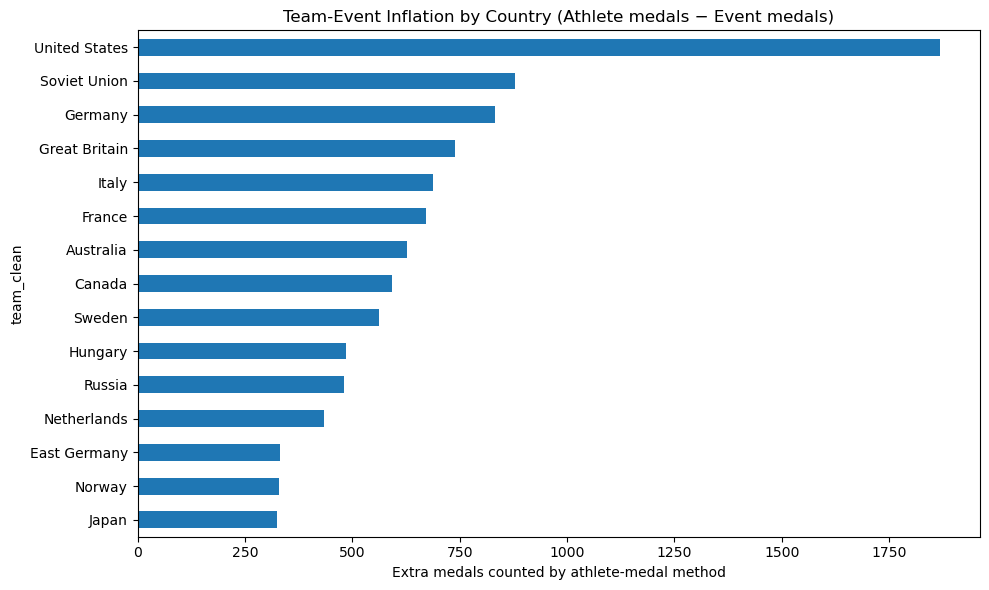

In [92]:
# SQ1 Plot) Inflation score
summary["inflation"] = summary["athlete_medals"] - summary["event_medals"]
top_inflation = summary.sort_values("inflation", ascending=False).head(15)["inflation"]

plt.figure(figsize=(10,6))
top_inflation.sort_values().plot(kind="barh")
plt.title("Team-Event Inflation by Country (Athlete medals − Event medals)")
plt.xlabel("Extra medals counted by athlete-medal method")
plt.tight_layout()
plt.savefig("figures/RQ2_SQ1_inflation_athlete_minus_event.png", dpi=300)
plt.show()


## SQ2 Plot: Rank changes when switching medal definitions (slope chart, one decade)

In [93]:
# Choose a decade (most recent by default)
decade_choice = int(df2["decade"].max())
print("Decade used:", decade_choice)

# Add decade columns to medal tables
medalists["decade"] = (medalists["year"] // 10) * 10
event_medals["decade"] = (event_medals["year"] // 10) * 10

df_dec = df2[df2["decade"] == decade_choice].copy()
med_dec = medalists[medalists["decade"] == decade_choice].copy()
evt_dec = event_medals[event_medals["decade"] == decade_choice].copy()

entries_d = df_dec.groupby("team_clean").size().rename("entries")
ath_d = med_dec.groupby("team_clean").size().rename("athlete_medals")
evt_d = evt_dec.groupby("team_clean").size().rename("event_medals")

dec = pd.concat([entries_d, ath_d, evt_d], axis=1).fillna(0)
dec["athlete_medals"] = dec["athlete_medals"].astype(int)
dec["event_medals"] = dec["event_medals"].astype(int)

# Filter for stability in this decade
dec = dec[(dec["entries"] >= 200) & (dec["event_medals"] >= 5)].copy()

# Ranks (1 = best)
dec["rank_athlete"] = dec["athlete_medals"].rank(ascending=False, method="dense")
dec["rank_event"] = dec["event_medals"].rank(ascending=False, method="dense")

# Take top 15 by event medals
top15 = dec.sort_values("event_medals", ascending=False).head(15).copy()
top15


Decade used: 2020


,entries,athlete_medals,event_medals,rank_athlete,rank_event
team_clean,,,,,
United States,1297,324,188,1.0,1.0
China,835,189,145,2.0,2.0
Japan,1129,162,110,5.0,3.0
Great Britain,844,172,107,3.0,4.0
France,1060,170,87,4.0,5.0
Australia,999,145,84,6.0,6.0
Italy,939,116,81,9.0,7.0
Germany,1051,123,78,8.0,8.0
Russia,501,129,68,7.0,9.0


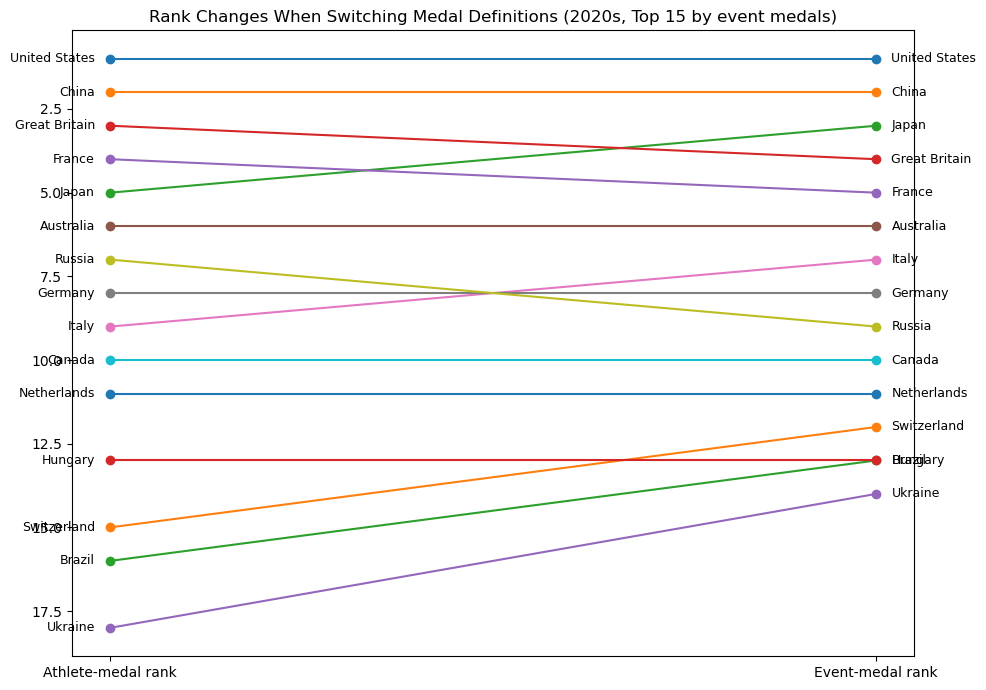

In [94]:
# SQ2 Plot) Slope chart: rank_athlete -> rank_event (top 15)
plot_df = top15.sort_values("rank_event", ascending=True)

plt.figure(figsize=(10,7))

for country in plot_df.index:
    ra = plot_df.loc[country, "rank_athlete"]
    re_ = plot_df.loc[country, "rank_event"]
    plt.plot([0, 1], [ra, re_], marker="o")

plt.xticks([0, 1], ["Athlete-medal rank", "Event-medal rank"])
plt.gca().invert_yaxis()

for country in plot_df.index:
    ra = plot_df.loc[country, "rank_athlete"]
    re_ = plot_df.loc[country, "rank_event"]
    plt.text(-0.02, ra, country, ha="right", va="center", fontsize=9)
    plt.text(1.02, re_, country, ha="left", va="center", fontsize=9)

plt.title(f"Rank Changes When Switching Medal Definitions ({decade_choice}s, Top 15 by event medals)")
plt.tight_layout()
plt.savefig("figures/RQ2_SQ2_slope_rank_change_one_decade.png", dpi=300)
plt.show()


## SQ3 Plot: Medal efficiency (event medals per 1000 entries)

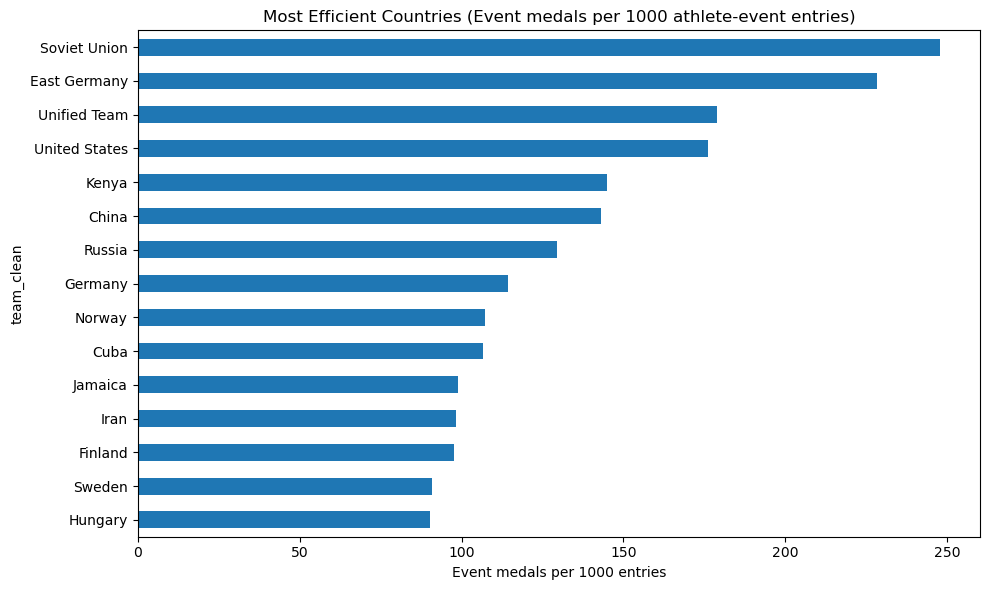

In [95]:
# SQ3 Plot) Efficiency = event medals per 1000 entries
summary["eff_event_per_1000"] = (summary["event_medals"] / summary["entries"]) * 1000
top_eff = summary.sort_values("eff_event_per_1000", ascending=False).head(15)["eff_event_per_1000"]

plt.figure(figsize=(10,6))
top_eff.sort_values().plot(kind="barh")
plt.title("Most Efficient Countries (Event medals per 1000 athlete-event entries)")
plt.xlabel("Event medals per 1000 entries")
plt.tight_layout()
plt.savefig("figures/RQ2_SQ3_efficiency_event_per_1000.png", dpi=300)
plt.show()


## SQ4 Plot: Inflation trend over decades

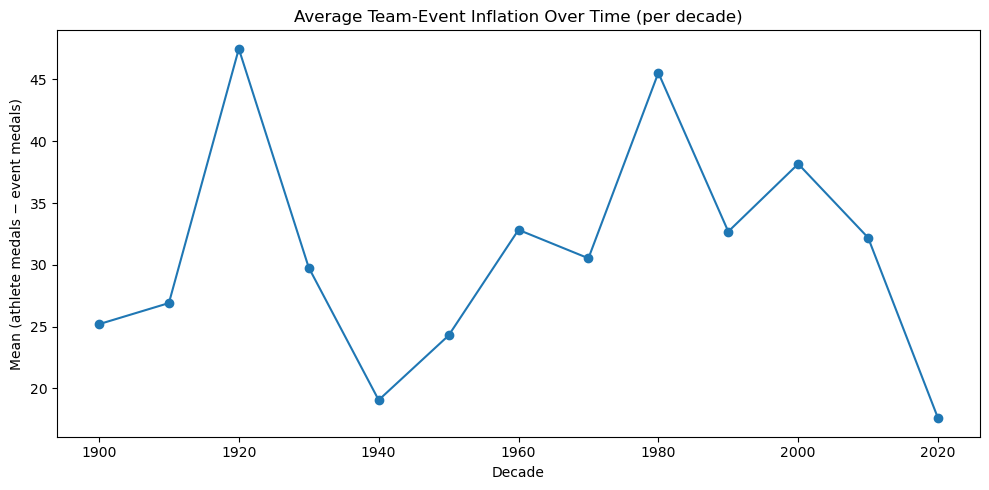

In [96]:
# SQ4 Plot) Average inflation per decade (athlete medals - event medals)

ath_dec = medalists.groupby(["decade","team_clean"]).size().rename("athlete_medals")
evt_dec = event_medals.groupby(["decade","team_clean"]).size().rename("event_medals")
ent_dec = df2.groupby(["decade","team_clean"]).size().rename("entries")

dec_tbl = pd.concat([ent_dec, ath_dec, evt_dec], axis=1).fillna(0)
dec_tbl["athlete_medals"] = dec_tbl["athlete_medals"].astype(int)
dec_tbl["event_medals"] = dec_tbl["event_medals"].astype(int)
dec_tbl["inflation"] = dec_tbl["athlete_medals"] - dec_tbl["event_medals"]

# Filter stable country-decades
dec_tbl = dec_tbl[(dec_tbl["entries"] >= 100) & (dec_tbl["event_medals"] >= 3)].copy()

trend = dec_tbl.groupby("decade")["inflation"].mean()

plt.figure(figsize=(10,5))
plt.plot(trend.index, trend.values, marker="o")
plt.title("Average Team-Event Inflation Over Time (per decade)")
plt.xlabel("Decade")
plt.ylabel("Mean (athlete medals − event medals)")
plt.tight_layout()
plt.savefig("figures/RQ2_SQ4_inflation_trend_by_decade.png", dpi=300)
plt.show()


## Additional RQ2 Visualizations (Variety)
These extra plots provide different perspectives (scatter, histogram, heatmap) to support RQ2.
Run them after the main SQ1–SQ4 plots.


### Extra Plot A: Athlete-medals vs Event-medals (scatter)
Shows how far countries deviate from the 1:1 line (team-event inflation).

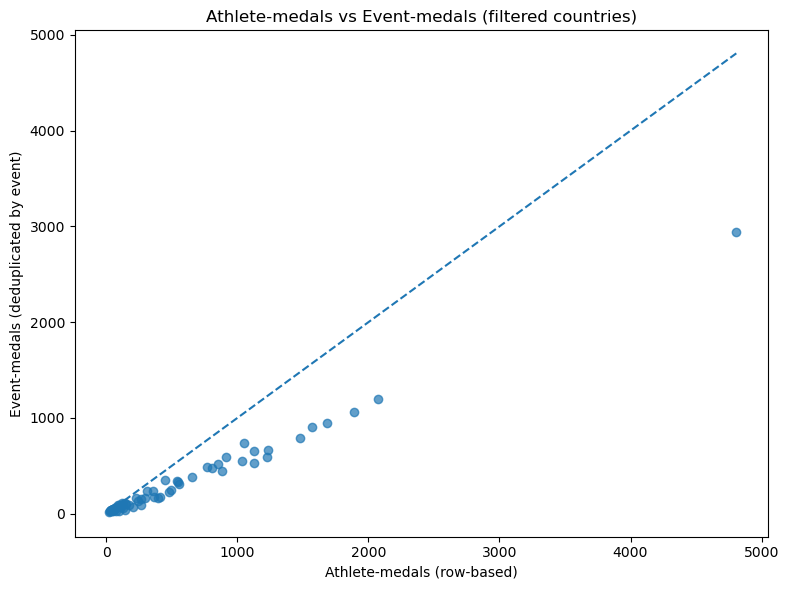

In [97]:
# Extra Plot A) Scatter: athlete_medals vs event_medals (all-years, filtered countries)

plt.figure(figsize=(8,6))
plt.scatter(summary["athlete_medals"], summary["event_medals"], alpha=0.7)

# 1:1 reference line
max_val = max(summary["athlete_medals"].max(), summary["event_medals"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.title("Athlete-medals vs Event-medals (filtered countries)")
plt.xlabel("Athlete-medals (row-based)")
plt.ylabel("Event-medals (deduplicated by event)")
plt.tight_layout()
plt.savefig("figures/RQ2_extraA_scatter_athlete_vs_event.png", dpi=300)
plt.show()


### Extra Plot B: Participation vs Efficiency (scatter)
Compares participation size (entries) with efficiency (event medals per 1000 entries).

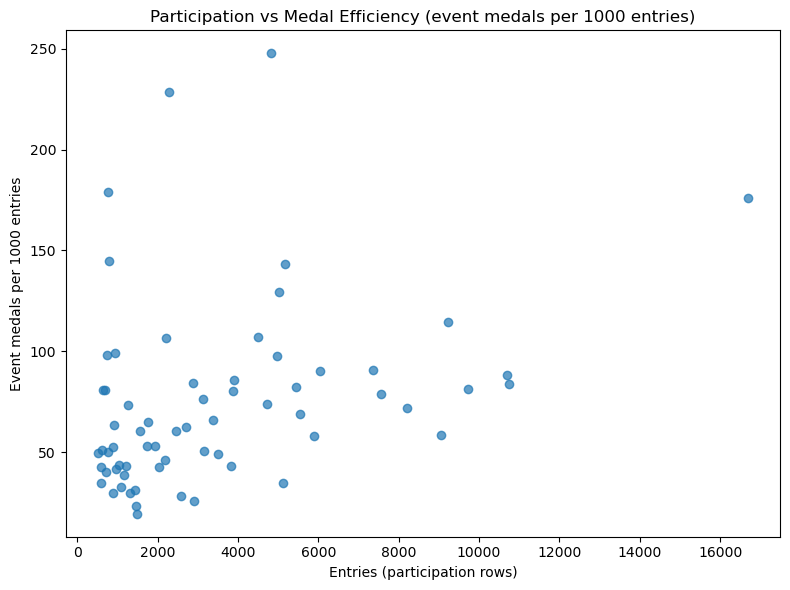

In [98]:
# Extra Plot B) Scatter: entries vs efficiency (event medals per 1000 entries)

plt.figure(figsize=(8,6))
plt.scatter(summary["entries"], summary["eff_event_per_1000"], alpha=0.7)

plt.title("Participation vs Medal Efficiency (event medals per 1000 entries)")
plt.xlabel("Entries (participation rows)")
plt.ylabel("Event medals per 1000 entries")
plt.tight_layout()
plt.savefig("figures/RQ2_extraB_scatter_entries_vs_efficiency.png", dpi=300)
plt.show()


### Extra Plot C: Distribution of rank changes (histogram)
Shows how common ranking changes are in the selected decade when switching methods.

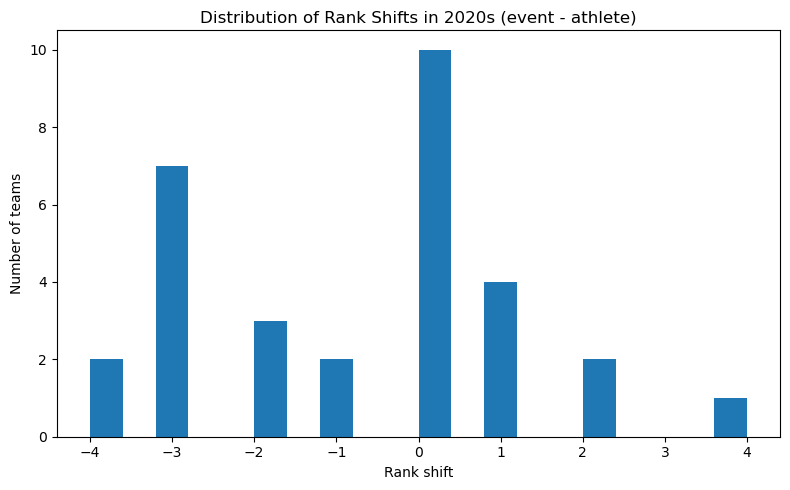

In [99]:
# Extra Plot C) Histogram of rank shifts in the chosen decade (all stable teams in that decade)

dec["rank_shift"] = dec["rank_event"] - dec["rank_athlete"]

plt.figure(figsize=(8,5))
plt.hist(dec["rank_shift"], bins=20)
plt.title(f"Distribution of Rank Shifts in {decade_choice}s (event - athlete)")
plt.xlabel("Rank shift")
plt.ylabel("Number of teams")
plt.tight_layout()
plt.savefig("figures/RQ2_extraC_hist_rank_shift_one_decade.png", dpi=300)
plt.show()


### Extra Plot D: Heatmap of rank shift across decades (top countries)
Visual summary of how rank changes vary across time for top medal countries.

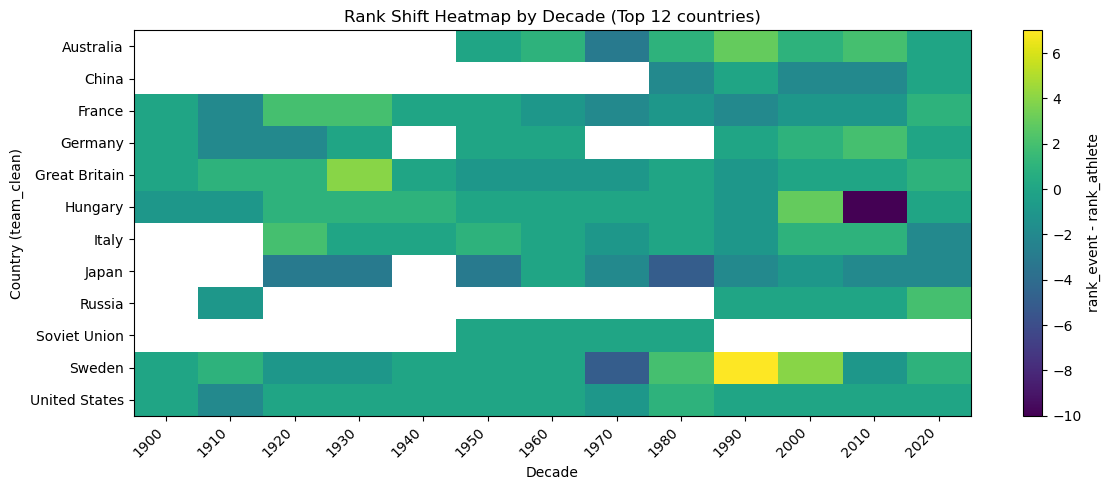

In [101]:
# Extra Plot D : Heatmap of rank shift across decades

# dec_tbl is likely a MultiIndex with (decade, team_clean) in the index,
# so convert it into real columns first:
dec_rank = dec_tbl.reset_index().copy()

# Rank within each decade using both counts
dec_rank["rank_athlete"] = dec_rank.groupby("decade")["athlete_medals"].rank(ascending=False, method="dense")
dec_rank["rank_event"]   = dec_rank.groupby("decade")["event_medals"].rank(ascending=False, method="dense")
dec_rank["rank_shift"]   = dec_rank["rank_event"] - dec_rank["rank_athlete"]

# Pick top 12 countries by total event medals
top_countries = (
    dec_rank.groupby("team_clean")["event_medals"].sum()
    .sort_values(ascending=False).head(12).index.tolist()
)

heat = (
    dec_rank[dec_rank["team_clean"].isin(top_countries)]
    .pivot_table(index="team_clean", columns="decade", values="rank_shift", aggfunc="mean")
)

plt.figure(figsize=(12,5))
plt.imshow(heat.values, aspect="auto", interpolation="nearest")
plt.title("Rank Shift Heatmap by Decade (Top 12 countries)")
plt.xlabel("Decade")
plt.ylabel("Country (team_clean)")
plt.xticks(range(len(heat.columns)), heat.columns, rotation=45, ha="right")
plt.yticks(range(len(heat.index)), heat.index)
plt.colorbar(label="rank_event - rank_athlete")
plt.tight_layout()
plt.savefig("figures/RQ2_extraD_heatmap_rank_shift_by_decade.png", dpi=300)
plt.show()

### Optional: Save extra summary outputs

In [102]:
# Optional exports for extra plots
heat.to_csv("outputs/rq2_rank_shift_heatmap_table.csv")
print("Saved outputs/rq2_rank_shift_heatmap_table.csv")


Saved outputs/rq2_rank_shift_heatmap_table.csv


### RQ2-6 (Optional): Export tables used in RQ2

In [103]:
# Optional exports
summary.to_csv("outputs/rq2_country_summary.csv", index=True)
top15.to_csv("outputs/rq2_top15_decade_rank_table.csv", index=True)
print("Saved outputs/rq2_country_summary.csv and outputs/rq2_top15_decade_rank_table.csv")


Saved outputs/rq2_country_summary.csv and outputs/rq2_top15_decade_rank_table.csv


# Research Question 3
## Diversification vs efficiency and rankings over time

**Main question:** Do countries win medals more efficiently when they spread success across many sports, or when they focus on a few sports—and how does this affect medal rankings over time?

### Sub-questions
- **RQ3a (Diversification):** How spread out are each country’s medals across sports?
- **RQ3b (Efficiency):** Are diversified countries more medal-efficient (event medals per participation)?
- **RQ3c (Rankings):** How does diversification relate to country rankings, and how do rankings evolve over decades?
- **RQ3d (Stability):** Are diversified countries more stable (less ups-and-downs) across decades?

**Goal:** Use all selected countries (target: 92) for overview plots, then analyze top/mid/bottom 20 based on efficiency.
Run cells in order.


### RQ3-1: Imports + folders

In [104]:
# RQ3-1) Imports (run once for RQ3)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


### RQ3-2: Prepare data (team cleaning + decade)

In [105]:
# RQ3-2) Prepare data
df = df_clean.copy()
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Decade for over-time analysis
df["decade"] = (df["year"] // 10) * 10

# Clean team names to reduce duplicates like 'India-1' vs 'India-2'
df["team_clean"] = df["team"].astype(str).str.replace(r"-\d+$", "", regex=True).str.strip()

print("Unique team_clean:", df["team_clean"].nunique())
print("Example team_clean:", df["team_clean"].dropna().unique()[:10])


Unique team_clean: 941
Example team_clean: ['Great Britain' 'Latvia' 'Austria' 'Netherlands' 'Sweden' 'Japan' 'Italy'
 'Uruguay' 'United States' 'Denmark']


### RQ3-3: Create medal tables (event-medal method)

In [106]:
# RQ3-3) Medalists and event-medals
medalists = df[df["medal"].isin(["Gold","Silver","Bronze"])].copy()

# Event medals: count each medal once per (year, event, country, medal)
event_medals = medalists.drop_duplicates(["year","event","team_clean","medal"]).copy()

print("Medalist rows:", medalists.shape)
print("Event-medal rows:", event_medals.shape)


Medalist rows: (36217, 16)
Event-medal rows: (20888, 16)


### RQ3-4: Build country summary metrics

In [108]:
# RQ3-4) Summary metrics per country

entries = df.groupby("team_clean").size().rename("entries")
event_counts = event_medals.groupby("team_clean").size().rename("event_medals")

# diversification metric (simple): how many sports with >=1 event medal
sports_medaled = event_medals.groupby("team_clean")["sports"].nunique().rename("sports_medaled")

summary = pd.concat([entries, event_counts, sports_medaled], axis=1).fillna(0)
summary["entries"] = summary["entries"].astype(int)
summary["event_medals"] = summary["event_medals"].astype(int)
summary["sports_medaled"] = summary["sports_medaled"].astype(int)

# Efficiency: event medals per 1000 entries
summary["eff_event_per_1000"] = (summary["event_medals"] / summary["entries"]) * 1000

summary.head()


,entries,event_medals,sports_medaled,eff_event_per_1000
team_clean,,,,
30. Februar,2,0,0,0.000000
A North American Team,3,1,1,333.333333
AIN,32,4,3,125.000000
Acipactli,3,0,0,0.000000
Acturus,1,0,0,0.000000


### RQ3-5: Compute concentration (HHI)

In [111]:
# RQ3-5) HHI concentration index (higher = more focused, lower = more diversified)

cs = event_medals.groupby(["team_clean","sports"]).size().rename("sport_medals").reset_index()
totals = cs.groupby("team_clean")["sport_medals"].sum().rename("total_medals")
cs = cs.merge(totals, on="team_clean", how="left")

cs["p"] = cs["sport_medals"] / cs["total_medals"]
hhi = cs.groupby("team_clean")["p"].apply(lambda x: (x**2).sum()).rename("HHI")

summary = summary.merge(hhi, on="team_clean", how="left").fillna({"HHI": 0})
summary.head()


,entries,event_medals,sports_medaled,eff_event_per_1000,HHI
team_clean,,,,,
30. Februar,2,0,0,0.000000,0.000
A North American Team,3,1,1,333.333333,1.000
AIN,32,4,3,125.000000,0.375
Acipactli,3,0,0,0.000000,0.000
Acturus,1,0,0,0.000000,0.000


### RQ3-6: Select 92 countries (stable & active)

In [112]:
# RQ3-6) Select exactly 92 countries for overview plots

# Filter tiny-sample noise (adjust thresholds if needed)
stable = summary[(summary["entries"] >= 300) & (summary["event_medals"] >= 10)].copy()

# Pick top 92 by entries (most active participants)
stable_92 = stable.sort_values("entries", ascending=False).head(92).copy()
print("Selected countries:", stable_92.shape[0])

stable_92.head()


Selected countries: 81


,entries,event_medals,sports_medaled,eff_event_per_1000,HHI
team_clean,,,,,
United States,16681,2939,64,176.188478,0.139371
France,10756,901,54,83.767200,0.061514
Great Britain,10691,944,57,88.298569,0.091831
Italy,9722,789,51,81.156141,0.063810
Germany,9238,1057,55,114.418705,0.046689


## RQ3 Plot 1 (All 92): Diversification vs efficiency (scatter)

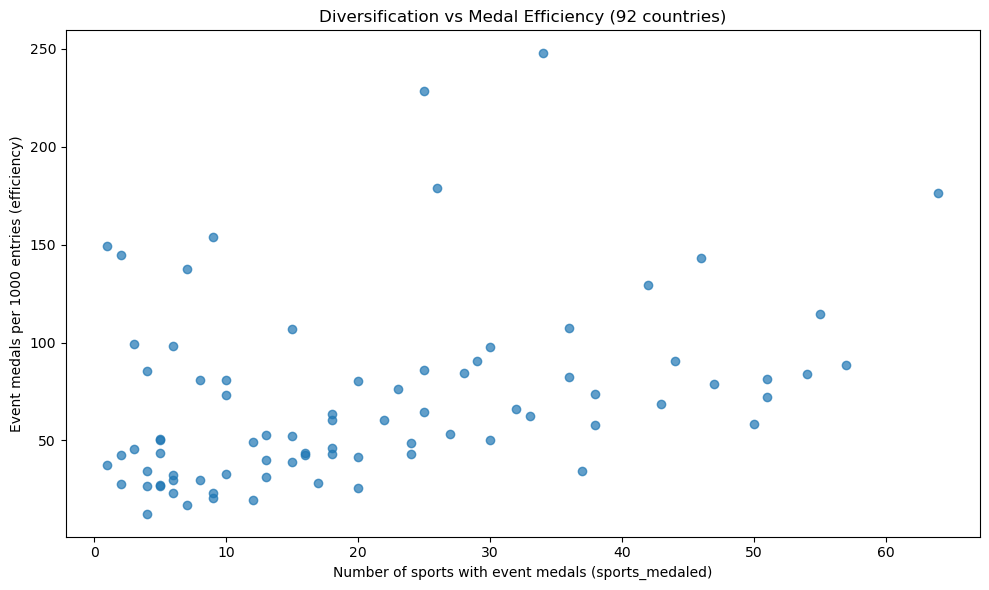

In [113]:
plt.figure(figsize=(10,6))
plt.scatter(stable_92["sports_medaled"], stable_92["eff_event_per_1000"], alpha=0.7)
plt.title("Diversification vs Medal Efficiency (92 countries)")
plt.xlabel("Number of sports with event medals (sports_medaled)")
plt.ylabel("Event medals per 1000 entries (efficiency)")
plt.tight_layout()
plt.savefig("figures/RQ3_plot1_scatter_sports_vs_efficiency.png", dpi=300)
plt.show()


## RQ3 Plot 2 (All 92): Concentration (HHI) vs efficiency (scatter)

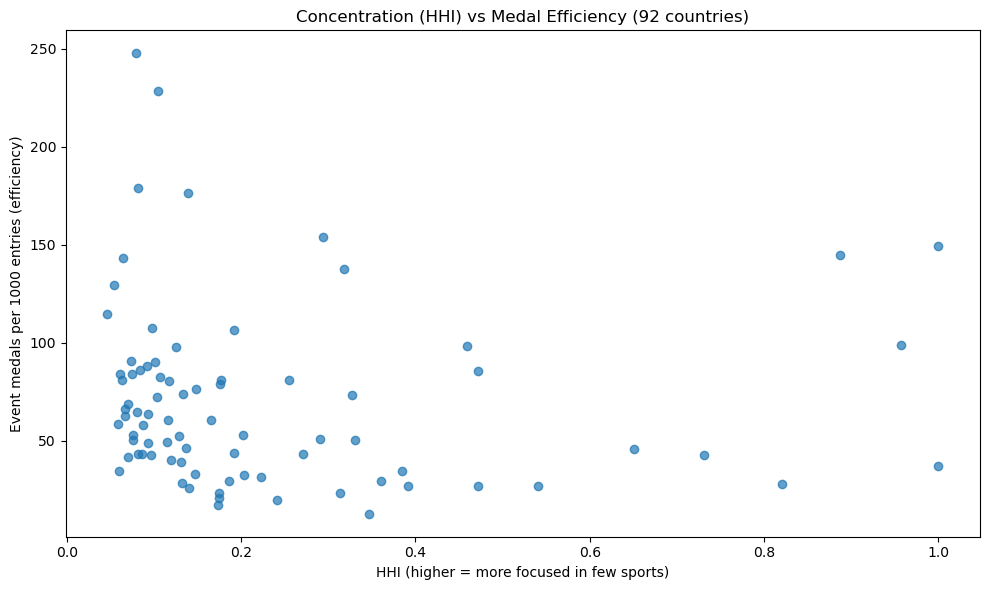

In [114]:
plt.figure(figsize=(10,6))
plt.scatter(stable_92["HHI"], stable_92["eff_event_per_1000"], alpha=0.7)
plt.title("Concentration (HHI) vs Medal Efficiency (92 countries)")
plt.xlabel("HHI (higher = more focused in few sports)")
plt.ylabel("Event medals per 1000 entries (efficiency)")
plt.tight_layout()
plt.savefig("figures/RQ3_plot2_scatter_HHI_vs_efficiency.png", dpi=300)
plt.show()


## RQ3 Plot 3 (All 92): Efficiency distribution (histogram)

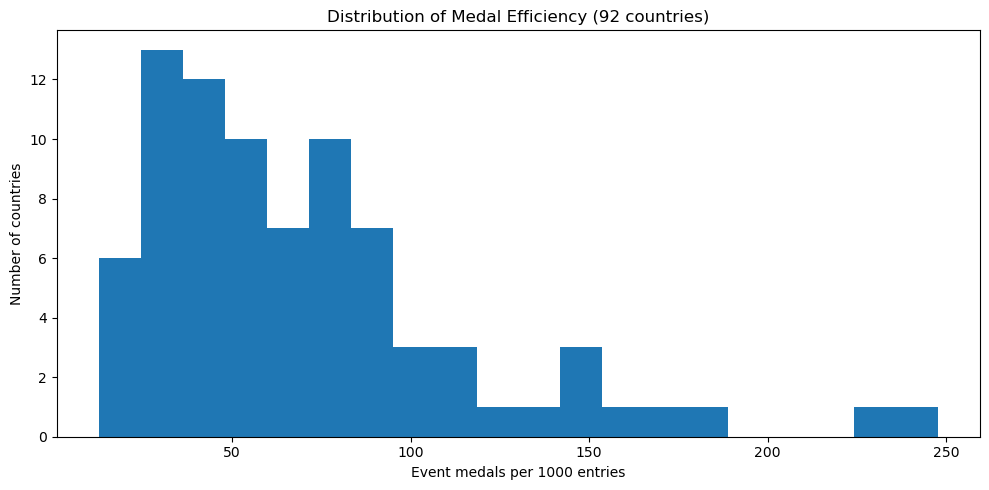

In [115]:
plt.figure(figsize=(10,5))
plt.hist(stable_92["eff_event_per_1000"], bins=20)
plt.title("Distribution of Medal Efficiency (92 countries)")
plt.xlabel("Event medals per 1000 entries")
plt.ylabel("Number of countries")
plt.tight_layout()
plt.savefig("figures/RQ3_plot3_hist_efficiency.png", dpi=300)
plt.show()


## RQ3 Plot 4 (All 92): Efficiency by diversification quartiles (boxplot)

C:\Users\princ\AppData\Local\Temp\ipykernel_31972\1839501060.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Low","Mid-Low","Mid-High","High"], showfliers=False)


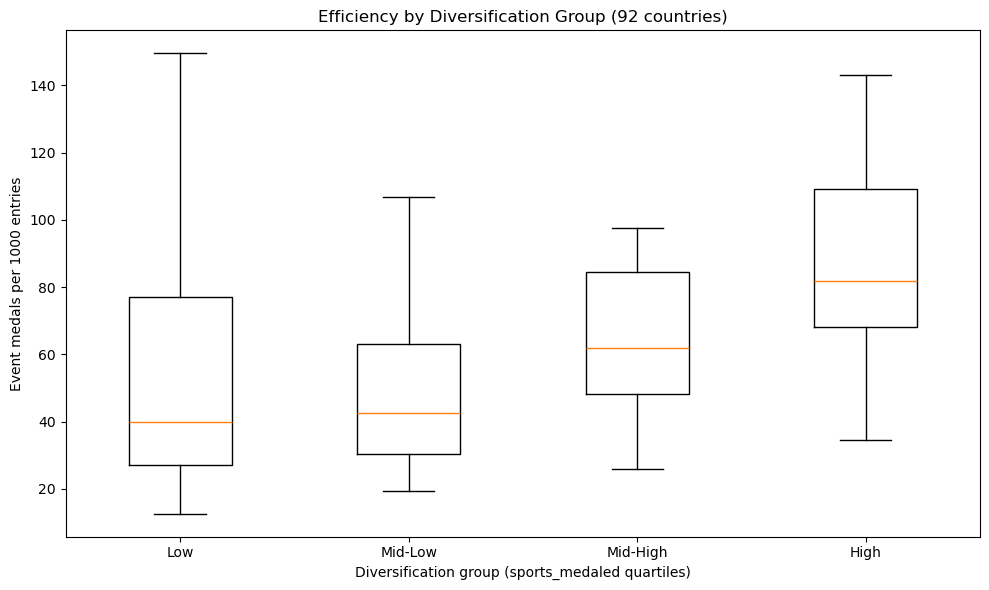

In [116]:
tmp = stable_92.copy()
tmp["div_group"] = pd.qcut(tmp["sports_medaled"], q=4, labels=["Low","Mid-Low","Mid-High","High"])

groups = [tmp[tmp["div_group"]==g]["eff_event_per_1000"].values for g in ["Low","Mid-Low","Mid-High","High"]]

plt.figure(figsize=(10,6))
plt.boxplot(groups, labels=["Low","Mid-Low","Mid-High","High"], showfliers=False)
plt.title("Efficiency by Diversification Group (92 countries)")
plt.xlabel("Diversification group (sports_medaled quartiles)")
plt.ylabel("Event medals per 1000 entries")
plt.tight_layout()
plt.savefig("figures/RQ3_plot4_box_eff_by_div_group.png", dpi=300)
plt.show()


### RQ3-7: Top 20 / Mid 20 / Bottom 20 (based on efficiency)

In [117]:
sorted_eff = stable_92.sort_values("eff_event_per_1000", ascending=False).copy()

top20 = sorted_eff.head(20)
bottom20 = sorted_eff.tail(20)
mid20 = sorted_eff.iloc[len(sorted_eff)//2 - 10 : len(sorted_eff)//2 + 10]

print("Top20 efficiency range:", top20["eff_event_per_1000"].min(), "to", top20["eff_event_per_1000"].max())
print("Mid20 efficiency range:", mid20["eff_event_per_1000"].min(), "to", mid20["eff_event_per_1000"].max())
print("Bottom20 efficiency range:", bottom20["eff_event_per_1000"].min(), "to", bottom20["eff_event_per_1000"].max())


Top20 efficiency range: 85.88957055214725 to 247.72162386081192
Mid20 efficiency range: 48.82924043403769 to 73.70644139387541
Bottom20 efficiency range: 12.671594508975714 to 37.234042553191486


## RQ3 Plot 5: Top 20 most efficient countries (bar chart)

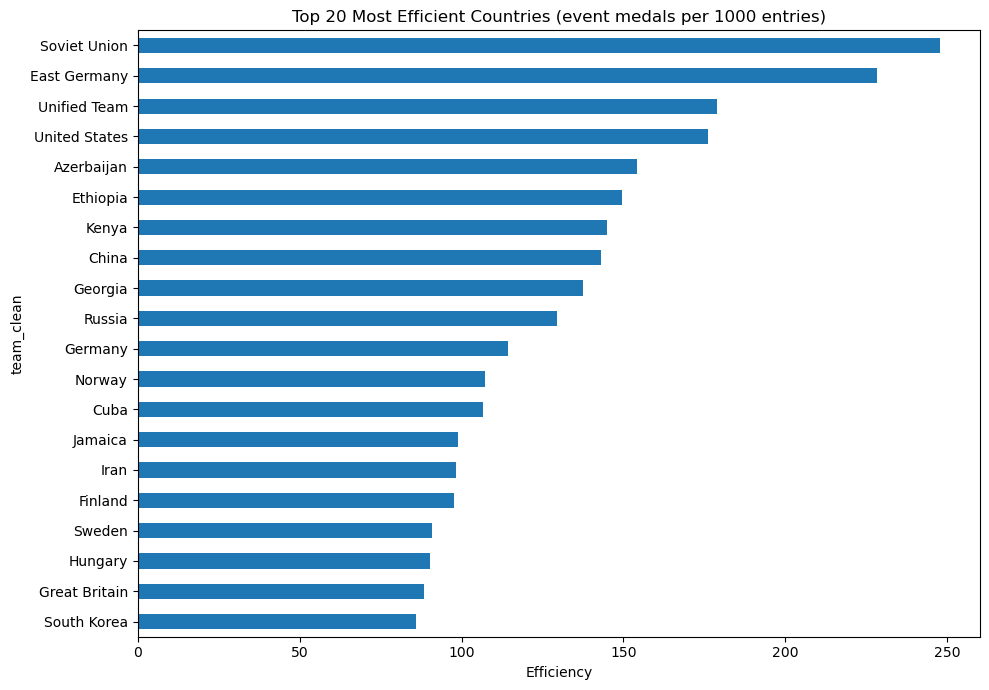

In [118]:
plt.figure(figsize=(10,7))
top20.sort_values("eff_event_per_1000")["eff_event_per_1000"].plot(kind="barh")
plt.title("Top 20 Most Efficient Countries (event medals per 1000 entries)")
plt.xlabel("Efficiency")
plt.tight_layout()
plt.savefig("figures/RQ3_plot5_top20_efficiency.png", dpi=300)
plt.show()


## RQ3 Plot 6: Bottom 20 least efficient countries (bar chart)

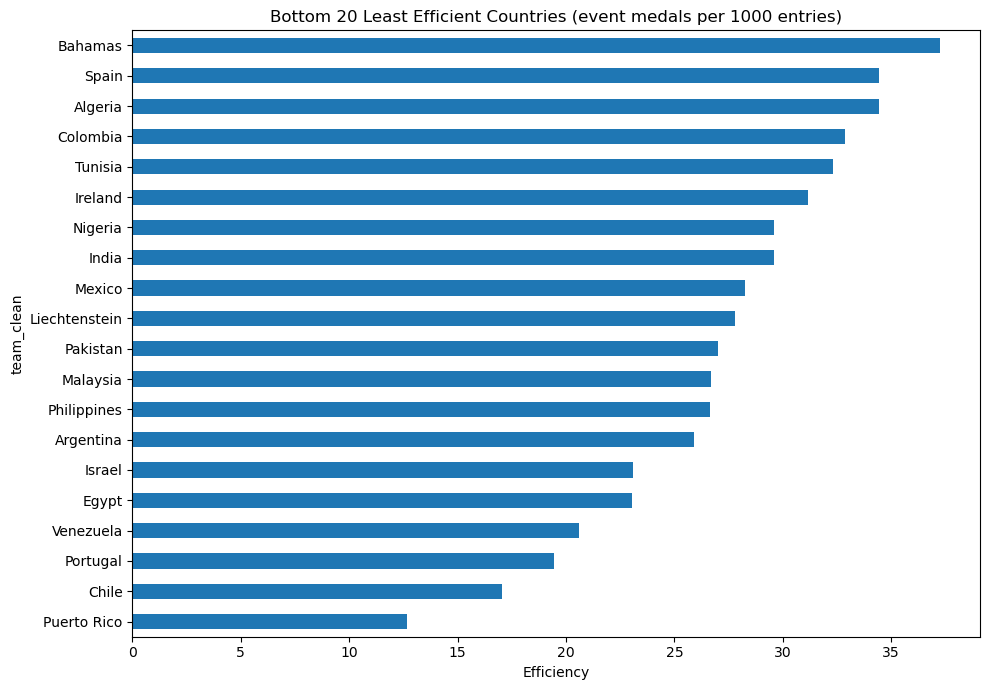

In [119]:
plt.figure(figsize=(10,7))
bottom20.sort_values("eff_event_per_1000")["eff_event_per_1000"].plot(kind="barh")
plt.title("Bottom 20 Least Efficient Countries (event medals per 1000 entries)")
plt.xlabel("Efficiency")
plt.tight_layout()
plt.savefig("figures/RQ3_plot6_bottom20_efficiency.png", dpi=300)
plt.show()


## RQ3 Plot 7: Compare diversification (Top vs Mid vs Bottom efficiency)

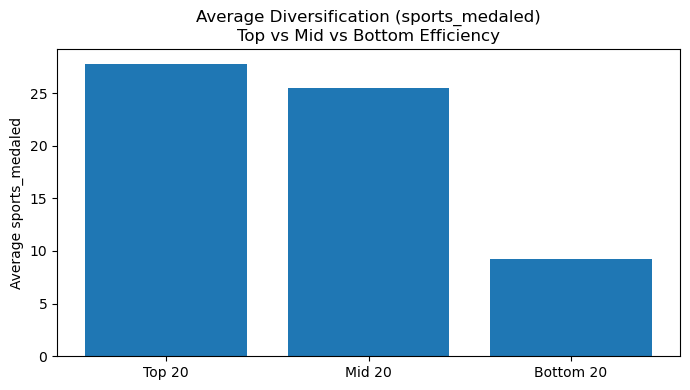

,Average sports_medaled
Top 20,27.80
Mid 20,25.45
Bottom 20,9.25


In [120]:
comp = pd.DataFrame({
    "Top 20": [top20["sports_medaled"].mean()],
    "Mid 20": [mid20["sports_medaled"].mean()],
    "Bottom 20": [bottom20["sports_medaled"].mean()]
}).T
comp.columns = ["Average sports_medaled"]

plt.figure(figsize=(7,4))
plt.bar(comp.index, comp["Average sports_medaled"].values)
plt.title("Average Diversification (sports_medaled)\nTop vs Mid vs Bottom Efficiency")
plt.ylabel("Average sports_medaled")
plt.tight_layout()
plt.savefig("figures/RQ3_plot7_compare_diversification_groups.png", dpi=300)
plt.show()

comp


### RQ3-8: Event-medal rankings over decades (selected 92 countries)

In [121]:
# Event medals per decade per country
evt_dec = event_medals.groupby(["decade","team_clean"]).size().rename("event_medals").reset_index()

# Keep only selected 92
evt_dec = evt_dec[evt_dec["team_clean"].isin(stable_92.index)].copy()

# Rank by decade (1 = best)
evt_dec["rank_event"] = evt_dec.groupby("decade")["event_medals"].rank(ascending=False, method="dense")

evt_dec.head()


,decade,team_clean,event_medals,rank_event
0,1890,Australia,2,8.0
2,1890,Austria,5,6.0
3,1890,Denmark,6,5.0
5,1890,France,11,3.0
6,1890,Germany,13,2.0


## RQ3 Plot 8: Heatmap of event-medal rank by decade (Top 20 efficient)

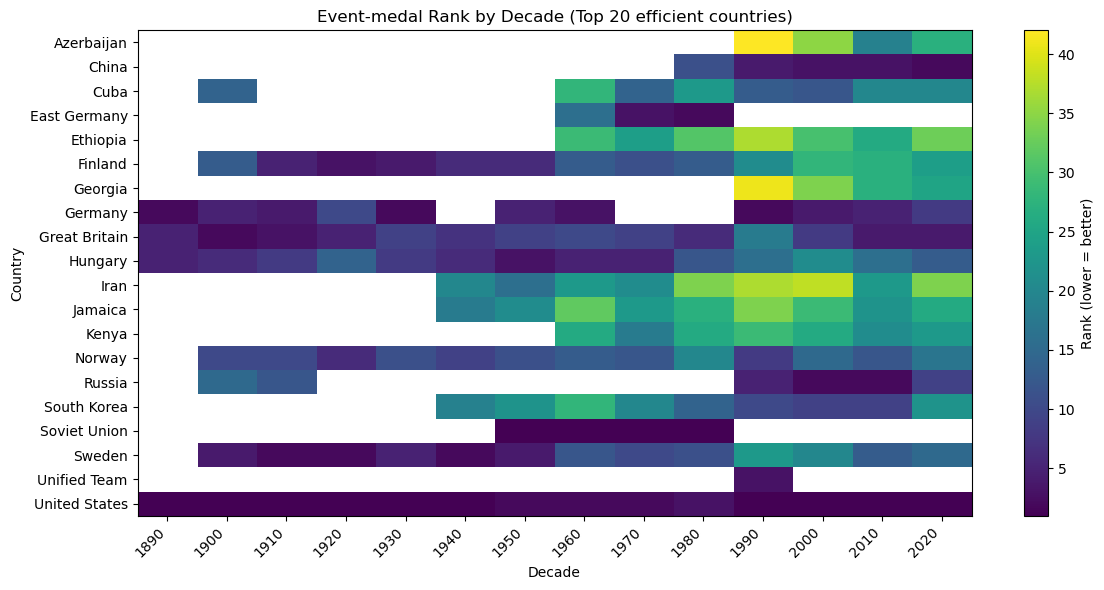

In [122]:
top20_names = top20.index.tolist()

heat_rank = evt_dec[evt_dec["team_clean"].isin(top20_names)].pivot_table(
    index="team_clean", columns="decade", values="rank_event", aggfunc="min"
)

plt.figure(figsize=(12,6))
plt.imshow(heat_rank.values, aspect="auto", interpolation="nearest")
plt.title("Event-medal Rank by Decade (Top 20 efficient countries)")
plt.xlabel("Decade")
plt.ylabel("Country")
plt.xticks(range(len(heat_rank.columns)), heat_rank.columns, rotation=45, ha="right")
plt.yticks(range(len(heat_rank.index)), heat_rank.index)
plt.colorbar(label="Rank (lower = better)")
plt.tight_layout()
plt.savefig("figures/RQ3_plot8_heatmap_rank_by_decade_top20.png", dpi=300)
plt.show()


## RQ3 Plot 9: Stability vs concentration (scatter)
Stability measured as CV = std/mean of event medals across decades.

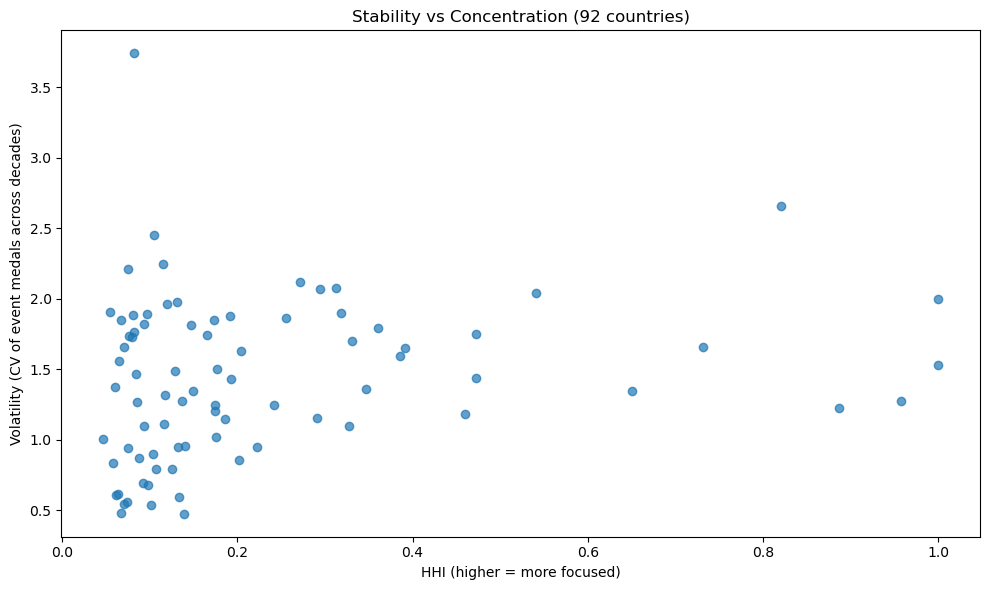

In [123]:
country_dec = evt_dec.pivot_table(index="team_clean", columns="decade", values="event_medals", aggfunc="sum").fillna(0)

mean_medals = country_dec.mean(axis=1)
std_medals = country_dec.std(axis=1)
cv = (std_medals / mean_medals.replace(0, np.nan)).rename("cv_medals")

stability = stable_92.merge(cv, left_index=True, right_index=True, how="left").fillna({"cv_medals": 0})

plt.figure(figsize=(10,6))
plt.scatter(stability["HHI"], stability["cv_medals"], alpha=0.7)
plt.title("Stability vs Concentration (92 countries)")
plt.xlabel("HHI (higher = more focused)")
plt.ylabel("Volatility (CV of event medals across decades)")
plt.tight_layout()
plt.savefig("figures/RQ3_plot9_scatter_HHI_vs_volatility.png", dpi=300)
plt.show()


### RQ3-9 (Optional): Export tables

In [124]:
stable_92.to_csv("outputs/rq3_country_metrics_92.csv", index=True)
top20.to_csv("outputs/rq3_top20_efficiency.csv", index=True)
mid20.to_csv("outputs/rq3_mid20_efficiency.csv", index=True)
bottom20.to_csv("outputs/rq3_bottom20_efficiency.csv", index=True)
print("Saved RQ3 outputs in outputs/")


Saved RQ3 outputs in outputs/
